In [1]:
import numpy as np
import matplotlib.pyplot as plt

def derivative_value(q, u, k, E):
    return (-q**3 - 3*k*q**2 -3*k**2*q+u*q + k*u - k**3)*(-2)/E

def get_all_roots(u, k, const, E):
    a = -1
    b = -4*k
    c = -6*k**2 + 2*u
    d = -4*k**3+4*u*k
    e = E**2 - u**2 + 2*k**2*u - k**4-const**2

    coefficients = [a, b, c, d, e]
    roots = np.roots(coefficients)
    
    roots_sorted = sorted(roots, key=lambda x: x.real)
    q1, q2, q3, q4 = roots_sorted
    
    all_real_roots = all(-1e-6 < abs(root.imag) < 1e-6 for root in roots_sorted)
    
    if all_real_roots:
        q_positive = []  # 导数 >= 0 的根
        q_negative = []  # 导数 < 0 的根
        
        for root in roots_sorted:
            deriv_val = derivative_value(root.real, u, k, E)
            if deriv_val > 10**(-10):
                q_positive.append(root)
            elif deriv_val < -10**(-10):
                q_negative.append(root)

        q_positive_sorted = sorted(q_positive, key=lambda x: x.real)
        q_negative_sorted = sorted(q_negative, key=lambda x: x.real)
        
        if len(q_positive_sorted) == 2 and len(q_negative_sorted) == 2:
            q22, q44 = q_positive_sorted[0], q_positive_sorted[1]
            q11, q33 = q_negative_sorted[0], q_negative_sorted[1]

    else:
        if E<0 and k>0:
        
            q22, q11, q44, q33= roots_sorted
        if E>0 and k>0:
        
            q11, q22, q33, q44 = roots_sorted
        if E<0 and k<0:
    
            q22, q11, q44, q33 = roots_sorted
        if E>0 and k<0:
        
            q11, q22, q33, q44 = roots_sorted

    return q11, q22, q33, q44

In [17]:
#const=0 方案2
import numpy as np
import matplotlib.pyplot as plt

def derivative_value(q, u, k, E):
    return (2*q**3 - 2*k**2*q-2*u*q + 2*k*E)/(E-2*k*q)
def get_all_roots(u, k, const, E):
    a = -1
    b = 0
    c = 2*k**2 + 2*u
    d = -4*k*E
    e = E**2 - u**2 + 2*k**2*u - k**4-const**2
    
    coefficients = [a, b, c, d, e]
    roots = np.roots(coefficients)
    
    roots_sorted = sorted(roots, key=lambda x: x.real)
    q1, q2, q3, q4 = roots_sorted
    
    all_real_roots = all(-1e-6 < abs(root.imag) < 1e-6 for root in roots_sorted)
    
    if all_real_roots:
        q_positive = []  
        q_negative = []  
        
        for root in roots_sorted:
            deriv_val = derivative_value(root.real, u, k, E)
            if deriv_val > 10**(-10):
                q_positive.append(root)
            elif deriv_val < -10**(-10):
                q_negative.append(root)
        q_positive_sorted = sorted(q_positive, key=lambda x: x.real)
        q_negative_sorted = sorted(q_negative, key=lambda x: x.real)

        if len(q_positive_sorted) == 2 and len(q_negative_sorted) == 2:
            q22, q44 = q_positive_sorted[0], q_positive_sorted[1]
            q11, q33 = q_negative_sorted[0], q_negative_sorted[1]
    else:
        if E<0:
            q11, q22, q44, q33 = roots_sorted
        if E>0:
            q11, q22, q33, q44 = roots_sorted
    return q11, q22, q33, q44

In [18]:
import os
import matplotlib.pyplot as plt
import numpy as np

u = 1000
k = 6
const = u/1000
q1_real = []
q2_real = []
q3_real = []
q4_real = []
q1_imag = []
q2_imag = []
q3_imag = []
q4_imag = []
E_set = np.linspace(-900*const, 900*const, 10000)

for E in E_set:
    q111, q222, q333, q444 = get_all_roots(u, k, const, E)
    
    q1_real.append(q111.real)
    q2_real.append(q222.real)
    q3_real.append(q333.real)
    q4_real.append(q444.real)
    
    q1_imag.append(q111.imag)
    q2_imag.append(q222.imag)
    q3_imag.append(q333.imag)
    q4_imag.append(q444.imag)

save_folder = r"D:\结果"
os.makedirs(save_folder, exist_ok=True)

plt.figure(figsize=(10, 6))
plt.subplot(1, 2, 1)
plt.plot(q1_real, E_set, label='q1_real')
plt.plot(q2_real, E_set, label='q2_real')
plt.plot(q3_real, E_set, label='q3_real')
plt.plot(q4_real, E_set, label='q4_real')
plt.axhline(y=0, color='k', linestyle='-', alpha=0.3)
plt.legend()
plt.grid(True, alpha=0.3)
#plt.ylim(0,20)
#plt.ylim(-1,1)
#plt.ylim(-360,-380)
#plt.xlim(10.00,20.09)
plt.xlim(30.95,31.25)
plt.ylim(370,375)
#plt.axhline(y=373.61, color='green', linestyle='-', linewidth=1, alpha=0.7)

plt.subplot(1, 2, 2)
plt.plot(q1_imag, E_set, label='q1_imag')
plt.plot(q2_imag, E_set, label='q2_imag')
plt.plot(q3_imag, E_set, label='q3_imag')
plt.plot(q4_imag, E_set, label='q4_imag')
plt.axhline(y=0, color='k', linestyle='-', alpha=0.3)
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(370,375)
#plt.axhline(y=373.61, color='green', linestyle='-', linewidth=1, alpha=0.7)
#plt.ylim(-8,8)
plt.tight_layout()

#save_path = os.path.join(save_folder, r"{a}.eps")
#plt.savefig(save_path, format='eps', bbox_inches='tight', dpi=300)

png_path = os.path.join(save_folder, r"{3}.png")
plt.savefig(png_path, format='png', bbox_inches='tight', dpi=300)


plt.close()
#print(f"图像已保存到: {save_path}")
print(f"PNG预览图已保存到: {png_path}")

PNG预览图已保存到: D:\结果\{3}.png


In [19]:
def liumidu(diyiyinzi,dieryinzi,xquan,k):
    didiyi=2*(diyiyinzi.conjugate()*(xquan)*diyiyinzi-dieryinzi.conjugate()*(xquan)*dieryinzi).imag
    didier=2*k*(diyiyinzi.conjugate()*diyiyinzi+dieryinzi.conjugate()*dieryinzi)
    return didiyi+didier

In [20]:
def calculate_probabilities_new_method(u, k, Z, E_set,quedingdewean):
    const = u/1000
    H = 2*Z*(u)**0.5 
    a_set = []
    b_set = []
    c_set = []
    d_set = []
    z_set = []
    z1_set=[]
    for E in E_set:
        if quedingdewean==1:
            qwei = get_all_roots(u, 10**(-6), 0 , E)[3]
            bf1 = 1
            bf2 = 0
        if quedingdewean==-1:
            qwei = get_all_roots(u, 10**(-6), 0 , E)[1]
            bf1 = 0
            bf2 = 1
        
        k2 = get_all_roots(u, k, const, E)[1].real+1j*abs(get_all_roots(u, k, const, E)[1].imag)
        cc1=((k2+k)**2-u-E)
        af1 = const/(abs(cc1)**2+const**2)**0.5
        af2 = -cc1/(abs(cc1)**2+const**2)**0.5
        #print(abs(af2)**2+abs(af1)**2)

        k4 =  get_all_roots(u, k, const, E)[3].real+1j*abs(get_all_roots(u, k, const, E)[3].imag)
        cc2=((k4+k)**2-u-E)
        cf1 = const/(abs(cc2)**2+const**2)**0.5
        cf2 = -cc2/(abs(cc2)**2+const**2)**0.5
        #print(abs(cf1)**2+abs(cf2)**2)

        q11 = get_all_roots(u, k, 0, E)[0]
        q33 = get_all_roots(u, k, 0, E)[2]

        zuihou1=cf1*(k4-q11-H/(1j))
        zuihou2=af1*(k2-q11-H/(1j))
        zuihou3=cf2*(k4-q33-H/(1j))
        zuihou4=af2*(k2-q33-H/(1j))
        weiba1=bf1*(qwei-q11)
        weiba2=bf2*(qwei-q33)
        d1=(weiba2-weiba1*zuihou3/zuihou1)/(zuihou4-zuihou2*zuihou3/zuihou1)
        c1=weiba1/zuihou1-d1*zuihou2/zuihou1
        b1 = c1*cf1 + d1*af1 - bf1
        a1 = c1*cf2 + d1*af2 - bf2
        
        ru= liumidu(bf1,bf2,1j*qwei,k)
        d11=liumidu(d1*af1,d1*af2,1j*k2,k)/ru
        c11=liumidu(c1*cf1,c1*cf2,1j*k4,k)/ru
        b11=-liumidu(b1,0,1j*q11,10**(-6))/ru
        a11=-liumidu(0,a1,1j*q33,10**(-6))/ru

        a_set.append(a11)
        b_set.append(b11)
        c_set.append(c11)
        d_set.append(d11)
        z_set.append(c11+d11+a11+b11)
        if quedingdewean==1:
            z1_set.append(1+a11 -b11)
        if quedingdewean==-1:
            z1_set.append(1+b11 -a11)

    return a_set, b_set, c_set, d_set, z_set, z1_set

c:\Users\taoji\anaconda3\Lib\site-packages\matplotlib\cbook.py:1699: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
c:\Users\taoji\anaconda3\Lib\site-packages\matplotlib\cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


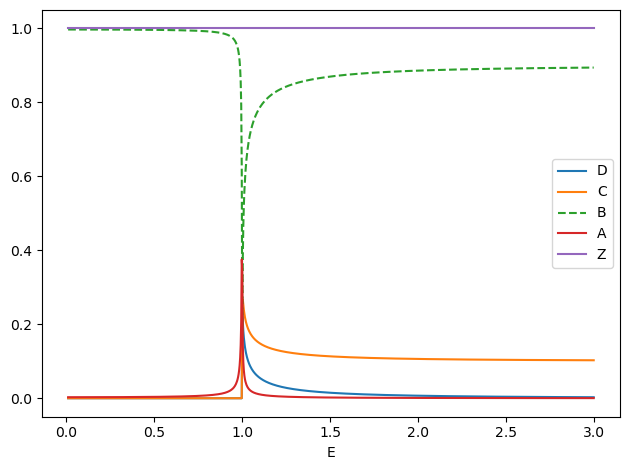

In [21]:
if __name__ == "__main__":
    u = 1000
    k = 10**(-6)
    Z = 3
    c_val = u/1000
    
    E_set1 = np.linspace(10**(-2)*c_val, 3*c_val, 1000)
    a_set1, b_set1, c_set1, d_set1, z_set1, z1_set1 = calculate_probabilities_new_method(u, k, Z, E_set1,1)
    #plt.figure(figsize=(5, 3))
    plt.plot(E_set1, d_set1, label='D')  
    plt.plot(E_set1, c_set1, label='C')
    plt.plot(E_set1, b_set1, label='B', linestyle='--')
    plt.plot(E_set1, a_set1, label='A')
    plt.plot(E_set1, z_set1, label='Z')
    #plt.plot(E_set1, z1_set1, label='G')
    plt.xlabel('E')
    plt.legend()
    plt.tight_layout()
    #plt.ylim(-0.1,1.1)
    plt.show()

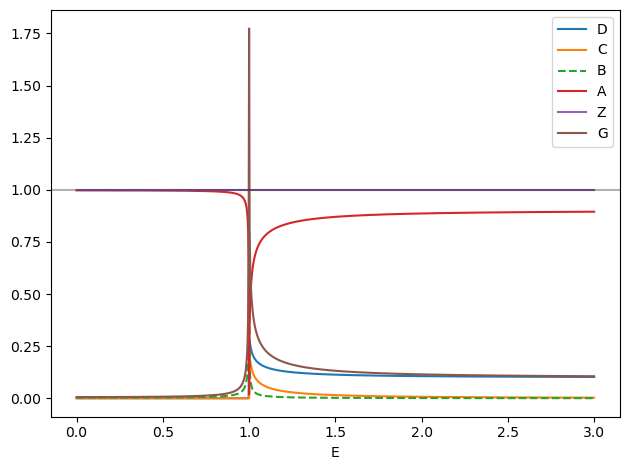

In [22]:
if __name__ == "__main__":
    u = 1000
    #k = 6
    k = 10**(-6)
    Z = 3
    c_val = u/1000
    E_set1 = np.linspace(0.00001*c_val, 3*c_val, 1000)
    #E_set1 = np.linspace(0.00001*c_val, 900*c_val, 1000)
    #E_set1 = np.linspace(370*c_val, 375*c_val, 1000)
    a_set1, b_set1, c_set1, d_set1, z_set1, z1_set1= calculate_probabilities_new_method(u, k, Z, E_set1,-1)
    #plt.figure(figsize=(5, 3))
    plt.plot(E_set1, d_set1, label='D')  
    plt.plot(E_set1, c_set1, label='C')
    plt.plot(E_set1, b_set1, label='B', linestyle='--')
    plt.plot(E_set1, a_set1, label='A')
    plt.plot(E_set1, z_set1, label='Z')
    plt.plot(E_set1, z1_set1, label='G')
    plt.axhline(y=1, color='k', linestyle='-', alpha=0.3)
    plt.xlabel('E')
    plt.legend()
    plt.tight_layout()
    #plt.ylim(-0.1,1.1)
    plt.show()

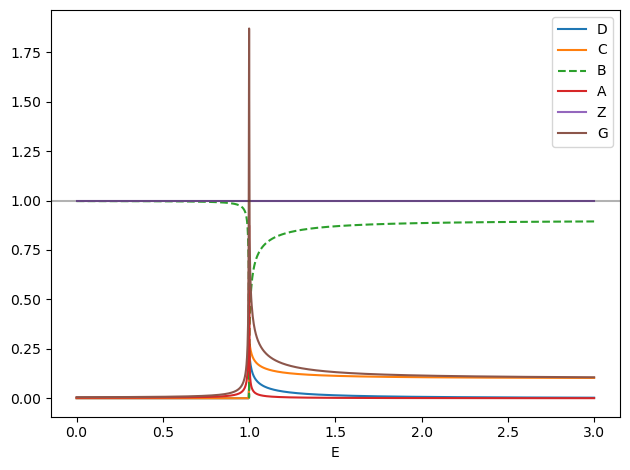

In [69]:
if __name__ == "__main__":
    u = 1000
    k = 10**(-10)
    #k=6
    Z = 3
    c_val = u/1000
    
    #E_set1 = np.linspace(0.00001*c_val, 900*c_val, 1000)
    E_set1 = np.linspace(0.00001*c_val, 3*c_val, 1000)
    #E_set1 = np.linspace(370*c_val, 375*c_val, 1000)
    a_set1, b_set1, c_set1, d_set1, z_set1,z1_set1 = calculate_probabilities_new_method(u, k, Z, E_set1,1)
    #plt.figure(figsize=(5, 3))
    plt.plot(E_set1, d_set1, label='D')  
    plt.plot(E_set1, c_set1, label='C')
    plt.plot(E_set1, b_set1, label='B', linestyle='--')
    plt.plot(E_set1, a_set1, label='A')
    plt.plot(E_set1, z_set1, label='Z')
    plt.plot(E_set1, z1_set1, label='G')
    plt.xlabel('E')
    plt.legend()
    plt.tight_layout()
    plt.axhline(y=1, color='k', linestyle='-', alpha=0.3)
    #plt.ylim(-0.1,1.1)
    plt.show()

In [15]:
if __name__ == "__main__":
    u = 1000
    #k = 6
    k = 0.005
    Z = 0.2
    c_val = u/1000
    E_set1 = np.linspace(0.00001*c_val, 3*c_val, 1000)
    #E_set1 = np.linspace(0.00001*c_val, 900*c_val, 1000)
    #E_set1 = np.linspace(370*c_val, 375*c_val, 1000)
    a_set1, b_set1, c_set1, d_set1, z_set1, z1_set1= calculate_probabilities_new_method(u, k, Z, E_set1,1)
    #plt.figure(figsize=(5, 3))
    plt.plot(E_set1, d_set1, label='D')  
    plt.plot(E_set1, c_set1, label='C')
    plt.plot(E_set1, b_set1, label='B', linestyle='--')
    plt.plot(E_set1, a_set1, label='A')
    plt.plot(E_set1, z_set1, label='Z')
    plt.plot(E_set1, z1_set1, label='G')
    plt.axhline(y=1, color='k', linestyle='-', alpha=0.3)
    plt.axhline(y=0.2, color='k', linestyle='-', alpha=0.3)
    plt.xlabel('E')
    plt.legend()
    plt.tight_layout()
    #plt.ylim(-0.1,1.1)
    plt.show()

UnboundLocalError: cannot access local variable 'q11' where it is not associated with a value

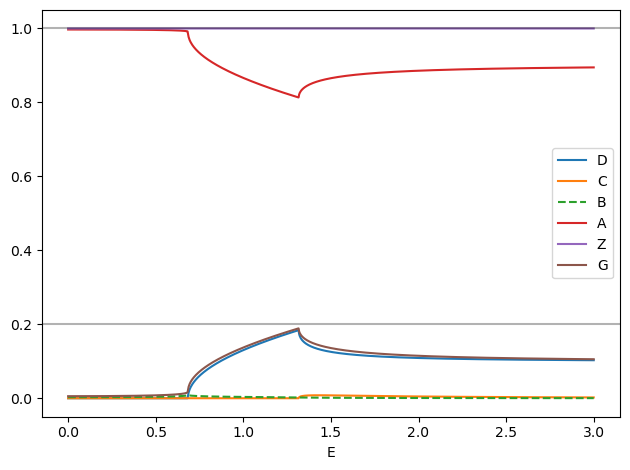

In [ ]:
if __name__ == "__main__":
    u = 1000
    #k = 6
    k = 0.005
    Z = 3
    c_val = u/1000
    E_set1 = np.linspace(0.00001*c_val, 3*c_val, 1000)
    #E_set1 = np.linspace(0.00001*c_val, 900*c_val, 1000)
    #E_set1 = np.linspace(370*c_val, 375*c_val, 1000)
    a_set1, b_set1, c_set1, d_set1, z_set1, z1_set1= calculate_probabilities_new_method(u, k, Z, E_set1,-1)
    #plt.figure(figsize=(5, 3))
    plt.plot(E_set1, d_set1, label='D')  
    plt.plot(E_set1, c_set1, label='C')
    plt.plot(E_set1, b_set1, label='B', linestyle='--')
    plt.plot(E_set1, a_set1, label='A')
    plt.plot(E_set1, z_set1, label='Z')
    plt.plot(E_set1, z1_set1, label='G')
    plt.axhline(y=1, color='k', linestyle='-', alpha=0.3)
    plt.axhline(y=0.2, color='k', linestyle='-', alpha=0.3)
    plt.xlabel('E')
    plt.legend()
    plt.tight_layout()
    #plt.ylim(-0.1,1.1)
    plt.show()

In [10]:
#const=0 方案2
import numpy as np
import matplotlib.pyplot as plt

def derivative_value(q, u, k, E):
    return (2*q**3 - 2*k**2*q-2*u*q + 2*k*E)/(E-2*k*q)
def get_all_roots(u, k, const, E):
    a = -1
    b = 0
    c = 2*k**2 + 2*u
    d = -4*k*E
    e = E**2 - u**2 + 2*k**2*u - k**4-const**2
    
    coefficients = [a, b, c, d, e]
    roots = np.roots(coefficients)
    
    roots_sorted = sorted(roots, key=lambda x: x.real)
    q1, q2, q3, q4 = roots_sorted
    
    all_real_roots = all(-1e-6 < abs(root.imag) < 1e-6 for root in roots_sorted)
    
    if all_real_roots:
        q_positive = []  
        q_negative = []  
        
        for root in roots_sorted:
            deriv_val = derivative_value(root.real, u, k, E)
            if deriv_val > 10**(-10):
                q_positive.append(root)
            elif deriv_val < -10**(-10):
                q_negative.append(root)
        q_positive_sorted = sorted(q_positive, key=lambda x: x.real)
        q_negative_sorted = sorted(q_negative, key=lambda x: x.real)

        if len(q_positive_sorted) == 2 and len(q_negative_sorted) == 2:
            q22, q44 = q_positive_sorted[0], q_positive_sorted[1]
            q11, q33 = q_negative_sorted[0], q_negative_sorted[1]
    else:
        if E<0:
            q11, q22, q44, q33 = roots_sorted
        if E>0:
            q11, q22, q33, q44 = roots_sorted
    return q11, q22, q33, q44

In [12]:
import numpy as np
import matplotlib.pyplot as plt

def derivative_value(q, u, k, E):
    return (-q**3 - 3*k*q**2 -3*k**2*q+u*q + k*u - k**3)*(-2)/E

def get_all_roots(u, k, const, E):
    a = -1
    b = -4*k
    c = -6*k**2 + 2*u
    d = -4*k**3+4*u*k
    e = E**2 - u**2 + 2*k**2*u - k**4-const**2

    coefficients = [a, b, c, d, e]
    roots = np.roots(coefficients)
    
    roots_sorted = sorted(roots, key=lambda x: x.real)
    q1, q2, q3, q4 = roots_sorted
    
    all_real_roots = all(-1e-6 < abs(root.imag) < 1e-6 for root in roots_sorted)
    
    if all_real_roots:
        q_positive = []  # 导数 >= 0 的根
        q_negative = []  # 导数 < 0 的根
        
        for root in roots_sorted:
            deriv_val = derivative_value(root.real, u, k, E)
            if deriv_val > 10**(-10):
                q_positive.append(root)
            elif deriv_val < -10**(-10):
                q_negative.append(root)

        q_positive_sorted = sorted(q_positive, key=lambda x: x.real)
        q_negative_sorted = sorted(q_negative, key=lambda x: x.real)
        
        if len(q_positive_sorted) == 2 and len(q_negative_sorted) == 2:
            q22, q44 = q_positive_sorted[0], q_positive_sorted[1]
            q11, q33 = q_negative_sorted[0], q_negative_sorted[1]

    else:
        if E<0 and k>0:
        
            q22, q11, q44, q33= roots_sorted
        if E>0 and k>0:
        
            q11, q22, q33, q44 = roots_sorted
        if E<0 and k<0:
       
            q22, q11, q44, q33 = roots_sorted
        if E>0 and k<0:
        
            q11, q22, q33, q44 = roots_sorted

    return q11, q22, q33, q44